<a href="https://colab.research.google.com/github/siinwook/Transformer-from-Scratch/blob/main/Transformer_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Transformer**

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

##Cuda

In [ ]:
if torch.cuda.is_available:
  device = 'cuda'
else:
  device = 'cpu'

##Positional Encoding

In [ ]:
class PositionalEncoding(nn.Module):
  def __init__(self,max_len,d_model):
    super().__init__()

    pos = torch.arange(0,max_len).unsqueeze(1) # (max_len,) -> (max_len,1)
    div_term = 1.0 / 10000**(torch.arange(0,d_model,2) / d_model)

    pe = torch.zeros((max_len,d_model))
    pe[:,0::2] = torch.sin(pos * div_term) # (max_len,d_model)
    pe[:,1::2] = torch.cos(pos * div_term)
    pe = pe.unsqueeze(0) # (1,max_len,d_model)

    self.register_buffer("pe", pe) # Non-trainable params, but included in model
    #self.pe = pe // not params, not buffer

  def forward(self,x):
    seq_len = x.size(1)

    return x + self.pe[:,:seq_len,:]

##MultiHead Attention

In [ ]:
import math

class MultiHeadAttention(nn.Module):
  def __init__(self, d_model, num_heads):
    super().__init__()

    d_k = d_model // num_heads

    self.d_model = d_model
    self.d_k = d_k
    self.num_heads = num_heads

    self.W_Q = nn.Linear(d_model,d_model)
    self.W_K = nn.Linear(d_model,d_model)
    self.W_V = nn.Linear(d_model,d_model)
    self.W_O = nn.Linear(d_model,d_model)

  def forward(self,q,k,v,mask=None):
    batch_size = q.size(0)

    # q,k,v -> Q,K,V
    Q = self.W_Q(q)
    K = self.W_K(k)
    V = self.W_V(v)

    # Multi head
    Q = Q.reshape(batch_size,-1,self.num_heads,self.d_k).transpose(1,2)
    K = K.reshape(batch_size,-1,self.num_heads,self.d_k).transpose(1,2)
    V = V.reshape(batch_size,-1,self.num_heads,self.d_k).transpose(1,2)

    # Attention
    attn_score = torch.matmul(Q, K.transpose(-1,-2)) / math.sqrt(self.d_k)
    if mask is not None:
      attn_score = torch.masked_fill(attn_score, mask==0, -1e9) # mask = [1, 1, 1, ... 0, 0, 0]
    attn_score = torch.softmax(attn_score, dim=-1)
    out = torch.matmul(attn_score, V)

    # Concatenate
    out = out.transpose(1,2).reshape(batch_size,-1,self.d_model)
    out = self.W_O(out)

    return out

##Feed-Forward Network

In [ ]:
class FeedForward(nn.Module):
  def __init__(self, d_model, d_ff):
    super().__init__()

    self.Sequential = nn.Sequential(
        nn.Linear(d_model, d_ff),
        nn.ReLU(),
        nn.Linear(d_ff,d_model)
    )

  def forward(self,x):
    x = self.Sequential(x)
    return x

##Encoder Block

In [ ]:
class EncoderBlock(nn.Module):
  def __init__(self, d_model, num_heads, d_ff, drop_out=0.1):
    super().__init__()

    self.MultiHeadAttn = MultiHeadAttention(d_model, num_heads)
    self.FFN = FeedForward(d_model, d_ff)

    self.LayerNorm1 = nn.LayerNorm(d_model)
    self.LayerNorm2 = nn.LayerNorm(d_model)

    self.Dropout = nn.Dropout(drop_out)

  def forward(self,x):
    attn_out = self.MultiHeadAttn(x,x,x,mask=None)
    x = self.LayerNorm1(x + self.Dropout(attn_out))

    ffn_out = self.FFN(x)
    x = self.LayerNorm2(x + self.Dropout(ffn_out))

    return x

##Decoder Block

In [ ]:
class DecoderBlock(nn.Module):
  def __init__(self, d_model, num_heads, d_ff, drop_out=0.1):
    super().__init__()

    self.num_heads = num_heads

    self.Masked_MultiHeadAttn = MultiHeadAttention(d_model, num_heads)
    self.MultiHeadAttn = MultiHeadAttention(d_model, num_heads)
    self.FFN = FeedForward(d_model, d_ff)

    self.LayerNorm1 = nn.LayerNorm(d_model)
    self.LayerNorm2 = nn.LayerNorm(d_model)
    self.LayerNorm3 = nn.LayerNorm(d_model)

    self.Dropout = nn.Dropout(drop_out)

  def forward(self, x, E):
    device = x.device

    batch_size = x.size(0)
    x_seq_len = x.size(1)

    mask = torch.ones(batch_size,self.num_heads,x_seq_len,x_seq_len).to(device)
    mask = torch.tril(mask)

    mask_attn_out = self.Masked_MultiHeadAttn(x,x,x,mask)
    x = self.LayerNorm1(x + self.Dropout(mask_attn_out))

    attn_out = self.MultiHeadAttn(x,E,E,mask=None)
    x = self.LayerNorm2(x + self.Dropout(attn_out))

    ffn_out = self.FFN(x)
    x = self.LayerNorm3(x + self.Dropout(ffn_out))

    return x

##Encoder

In [ ]:
class Encoder(nn.Module):
  def __init__(self, d_model, num_heads, d_ff, drop_out=0.1, N=6):
      super().__init__()

      self.N = N
      self.EncBlcockList = nn.ModuleList([
          EncoderBlock(d_model, num_heads, d_ff, drop_out)
          for i in range(N)
      ])

  def forward(self,x):
    for EncBlock in self.EncBlcockList:
      x = EncBlock(x)

    return x

##Decoder

In [ ]:
class Decoder(nn.Module):
  def __init__(self, d_model, num_heads, d_ff, drop_out=0.1, N=6):
      super().__init__()

      self.N = N
      self.DecBlcockList = nn.ModuleList([
          DecoderBlock(d_model, num_heads, d_ff, drop_out)
          for i in range(N)
      ])

  def forward(self, x, E):
    for DecBlock in self.DecBlcockList:
      x = DecBlock(x, E)

    return x

##Transformer

In [ ]:
import math

class Transformer(nn.Module):
  def __init__(self, src_vocab_size, tgt_vocab_size, max_len, d_model, num_heads, d_ff, drop_out, N):
    super().__init__()

    self.d_model = d_model

    self.src_Embedding = nn.Embedding(src_vocab_size, d_model)
    #self.tgt_Embedding = nn.Embedding(tgt_vocab_size, d_model)
    self.tgt_Embedding = self.src_Embedding # Weight tying for joint BPE

    self.Pos_Encoding = PositionalEncoding(max_len,d_model)

    nn.init.normal_(self.src_Embedding.weight, 0, 1.0 / math.sqrt(d_model)) # Xavier init
    nn.init.normal_(self.tgt_Embedding.weight, 0, 1.0 / math.sqrt(d_model))

    self.Encoder = Encoder(d_model, num_heads, d_ff, drop_out, N)
    self.Decoder = Decoder(d_model, num_heads, d_ff, drop_out, N)

    self.FC = nn.Linear(d_model, tgt_vocab_size)
    self.FC.weight = self.tgt_Embedding.weight # Weight tying as the paper

  def forward(self, src, tgt):
    src_embed = self.src_Embedding(src) * math.sqrt(self.d_model) # Scaling for PE
    src_embed = self.Pos_Encoding(src_embed)

    tgt_embed = self.tgt_Embedding(tgt) * math.sqrt(self.d_model) # Scaling for PE
    tgt_embed = self.Pos_Encoding(tgt_embed)

    E = self.Encoder(src_embed)
    D = self.Decoder(tgt_embed, E)

    out = self.FC(D)

    return out

##Multi30K with joint Byte-Pair Encoding

In [ ]:
from torch.utils.data import DataLoader, Dataset

PAD_IDX = 0
BOS_IDX = 1
EOS_IDX = 2

VOCAB_SIZE = 5000

class multi30k_en2de(Dataset):
  def __init__(self, data, num_samples, tokenizer, vocab_size):
    self.num_samples = num_samples

    data = self.lower(data)
    self.data = data

    tokenizer.train_from_iterator(self.data[:]["en"] + self.data[:]["de"], vocab_size = vocab_size, special_tokens= ["<pad>", "<bos>", "<eos>"]) # joint BPE
    self.tokenizer = tokenizer

    self.bos_id = tokenizer.token_to_id("<bos>")
    self.eos_id = tokenizer.token_to_id("<eos>")

  def lower(self, data):
    for idx in range(len(data)):
      data[idx]["en"] = data[idx]["en"].lower()
      data[idx]["de"] = data[idx]["de"].lower()

    return data

  def tokenize(self, sentence, target = False, label = False):
    out = self.tokenizer.encode(sentence).ids

    # source: <bos> + sentence + <eos>
    # target: <bos> + sentence
    # label: sentence + <eos>

    if not label:
      out = [self.bos_id] + out
    if not target:
      out = out + [self.eos_id]

    return torch.tensor(out)

  def __len__(self):
    return self.num_samples

  def __getitem__(self, idx):
    en = self.data[idx]['en']
    de = self.data[idx]['de']

    token_en = self.tokenize(en, target = False, label = False)
    token_de = self.tokenize(de, target = True, label = False)

    token_label = de = self.tokenize(de, target = False, label = True)

    return {'src':token_en, 'tgt':token_de, 'label':token_label} # en -> de

In [ ]:
from datasets import load_dataset # HF
from tokenizers import ByteLevelBPETokenizer # HF
from torch.nn.utils.rnn import pad_sequence

multi30k = load_dataset("bentrevett/multi30k")
multi30k_train = multi30k['train']

tokenizer = ByteLevelBPETokenizer()

def collate_fn(batch):
  src = [item['src'] for item in batch]
  tgt = [item['tgt'] for item in batch]
  label = [item['label'] for item in batch]

  padded_src = pad_sequence(src, batch_first = True, padding_value = PAD_IDX)
  padded_tgt = pad_sequence(tgt, batch_first = True, padding_value = PAD_IDX)
  padded_label = pad_sequence(label, batch_first = True, padding_value = PAD_IDX)

  return {'src':padded_src, 'tgt':padded_tgt, 'label':padded_label}

dataset = multi30k_en2de(data = multi30k_train, num_samples = len(multi30k_train), tokenizer = tokenizer, vocab_size = VOCAB_SIZE)
dataloader = DataLoader(dataset, batch_size = 64, shuffle = True, collate_fn = collate_fn)

##Training

In [ ]:
model = Transformer(src_vocab_size = VOCAB_SIZE, tgt_vocab_size= VOCAB_SIZE, max_len = 75, d_model = 192, num_heads = 8, d_ff = 784, drop_out = 0.1, N = 6).to(device)

In [ ]:
train_loss = []

In [ ]:
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
epochs=[25,25]
lrs=[1e-4,5e-5]

train_loss = []
for i in range(len(epochs)):
  optimizer = torch.optim.Adam(model.parameters(), lr = lrs[i])
  for epoch in range(epochs[i]):
    model.train()
    epoch_loss = 0

    for batch, sentences in enumerate(dataloader):
      src = sentences['src']
      tgt_input = sentences['tgt']
      tgt_label = sentences['label']

      src = src.to(device)
      tgt_input = tgt_input.to(device)
      tgt_label = tgt_label.to(device)

      logits = model(src, tgt_input)

      logits = logits.reshape(-1, logits.size(-1))
      tgt_label = tgt_label.reshape(-1)

      optimizer.zero_grad()
      loss = loss_fn(logits,tgt_label)
      loss.backward()
      optimizer.step()

      epoch_loss += loss.item()

    print(f"epoch {sum(epochs[:i])+epoch+1} loss: {epoch_loss / len(dataloader)}")
    train_loss.append(epoch_loss / len(dataloader))

##Inference

In [ ]:
import math

tokenizer = dataset.tokenizer

test_src = "A trendy girl talking on her cellphone while gliding slowly down the street." # multi30k['test']

src_token = tokenizer.encode(test_src).ids
src_token = [BOS_IDX] + src_token + [EOS_IDX]

model.eval()
with torch.no_grad():
  src_token = torch.tensor([src_token]).to(device)
  src_embed = model.src_Embedding(src_token) * math.sqrt(model.d_model)
  src_embed = model.Pos_Encoding(src_embed)

  E = model.Encoder(src_embed)

  test_tgt = torch.tensor([[BOS_IDX]]).to(device)

  for i in range(20):
    tgt_embed = model.tgt_Embedding(test_tgt) * math.sqrt(model.d_model)
    tgt_embed = model.Pos_Encoding(tgt_embed)

    out = model.Decoder(tgt_embed, E)
    out = model.FC(out)

    out = out[:,-1,:].argmax(dim=-1).item()

    test_tgt= torch.cat((test_tgt,torch.tensor([[out]]).to(device)),dim=-1)

    if out == EOS_IDX:
      break

test_tgt = test_tgt.cpu()
out = tokenizer.decode(test_tgt[0].tolist())

print(out)

Ein schickes Mädchen spricht mit dem Handy während sie langsam die Straße entlangschwiese Person


It means, "A chic girl talks on her mobile phone while slowly walking down the street."

##Loss curve

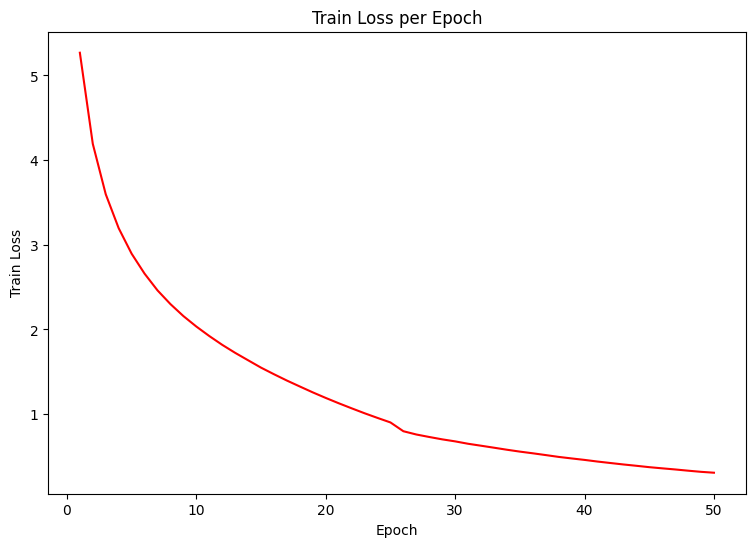

In [ ]:
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(9, 6))

plt.plot(epochs, train_loss, "r-", label="Multi30k Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Train Loss per Epoch")

plt.show()